# Lab 3 Task 1: Modulation, Detection, and Error Rate

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

Lab root: /Users/marcpham/jupyter_notebook_files/Embedded-Wireless-Design-Labs/Lab3


## PSK mapping, detector, and theory

In [2]:
from scipy import integrate, special
from lab3_dsp import gray_decode, integers_to_bits
from lab3_tools import simulate_awgn_point, plot_error_rate_results, plot_constellation_snapshots

def psk_constellation(order):
    labels = np.arange(order, dtype=np.int64)
    # To Do: map Gray labels to physical phase indices.
    phase_index = gray_decode(labels)
    # To Do: return the unit-energy PSK points.
    return np.exp(1j * 2 * np.pi * phase_index / order)

def minimum_distance_detector(received, constellation):
    # To Do: calculate squared Euclidean distance to every point.
    distance_squared = np.abs(received[:, None] - constellation[None, :])**2
    # To Do: return the closest constellation index for each sample.
    return np.argmin(distance_squared, axis=1)

def psk_theory_from_ebn0(order, ebn0_db):
    bits_per_symbol = int(np.log2(order))
    # To Do: convert Eb/N0 in dB to linear Es/N0.
    gamma_s = bits_per_symbol * (10**(np.asarray(ebn0_db) / 10))
    upper = (order - 1) * np.pi / order
    values = []
    for value in np.atleast_1d(gamma_s):
        coefficient = value * np.sin(np.pi / order)**2
        def integrand(theta):
            sine = np.sin(theta)
            return 0.0 if abs(sine) < 1e-14 else np.exp(-coefficient / sine**2)
        # To Do: evaluate the coherent M-PSK integral.
        values.append((integrate.quad(integrand, 0, upper)[0]) / np.pi)
    return np.asarray(values)

In [3]:
for order in (2, 4, 8, 16, 32):
    points = np.asarray(psk_constellation(order))
    assert points.size == order
    assert np.isclose(np.mean(np.abs(points)**2), 1.0)
    assert np.array_equal(minimum_distance_detector(points, points), np.arange(order))
print("PSK geometry and noiseless detection passed.")

PSK geometry and noiseless detection passed.


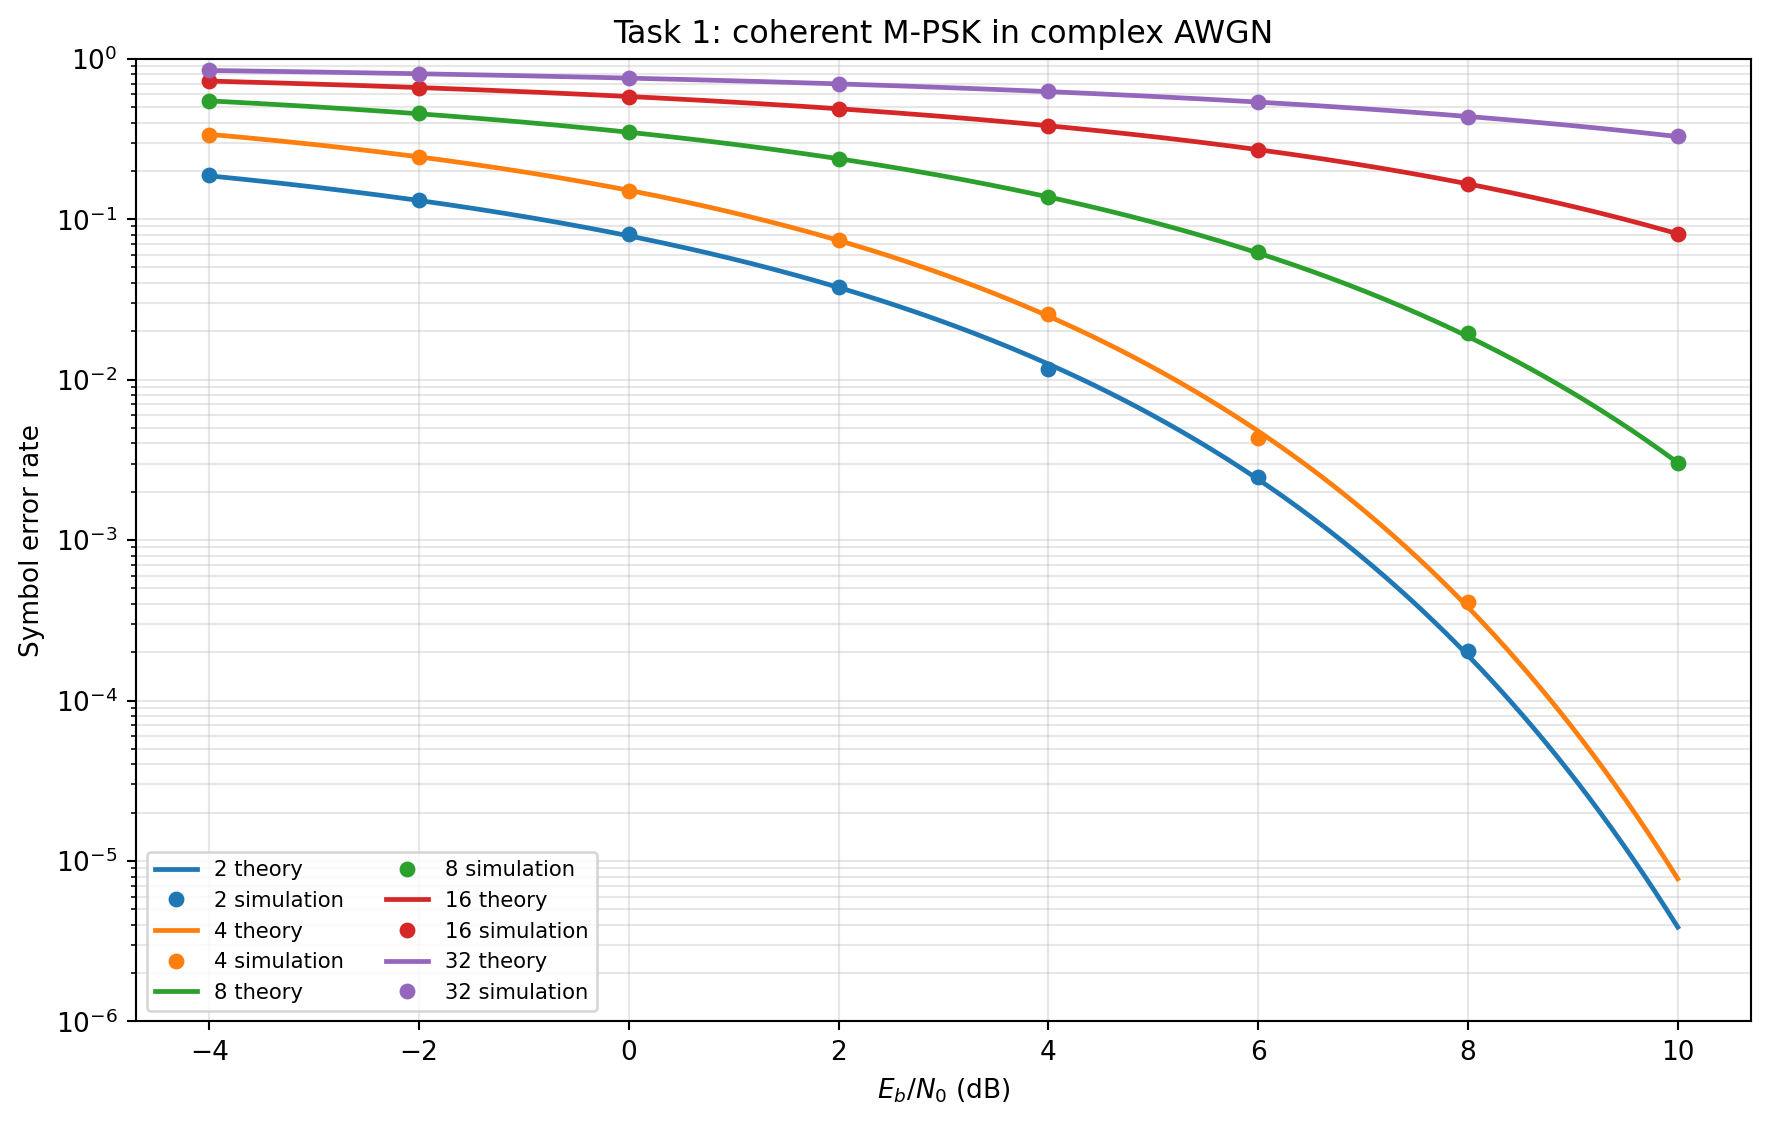

In [4]:
rng = np.random.default_rng(7377)
psk_results = {}
for order in (2, 4, 8, 16, 32):
    constellation = psk_constellation(order)
    psk_results[order] = [
        simulate_awgn_point(constellation, ebn0, rng, minimum_distance_detector)
        for ebn0 in np.arange(-4.0, 10.1, 2.0)
    ]
psk_figure = plot_error_rate_results(
    psk_results, psk_theory_from_ebn0,
    "Task 1: coherent M-PSK in complex AWGN",
    FIGURE_DIR, "task1_psk_error_rates"
)
display(Image(filename=str(psk_figure)))

## Square QAM mapping and theory

In [5]:
def square_qam_constellation(order):
    side = int(np.sqrt(order))
    axis_bits = int(np.log2(side))
    labels = np.arange(order, dtype=np.int64)
    i_labels = labels >> axis_bits
    q_labels = labels & (side - 1)
    levels = 2*np.arange(side) - (side - 1)
    # To Do: Gray map each axis and form the complex grid.
    points = levels[gray_decode(i_labels)] + 1j * levels[gray_decode(q_labels)]
    # To Do: normalize the complete constellation to unit average energy.
    return points / np.sqrt(np.mean(np.abs(points)**2))

def qam_theory_from_ebn0(order, ebn0_db):
    bits_per_symbol = int(np.log2(order))
    # To Do: convert Eb/N0 to linear Es/N0.
    gamma_s = bits_per_symbol * 10**(np.array(ebn0_db) / 10.0)
    # To Do: evaluate Q(x) and the square-QAM SER expression.
    q_value = 0.5 * special.erfc((np.sqrt(3 * gamma_s / (order - 1)) / np.sqrt(2)))
    return 1 - (1 - 2 * (1 - 1 / np.sqrt(order)) * q_value)**2

QAM geometry and noiseless detection passed.


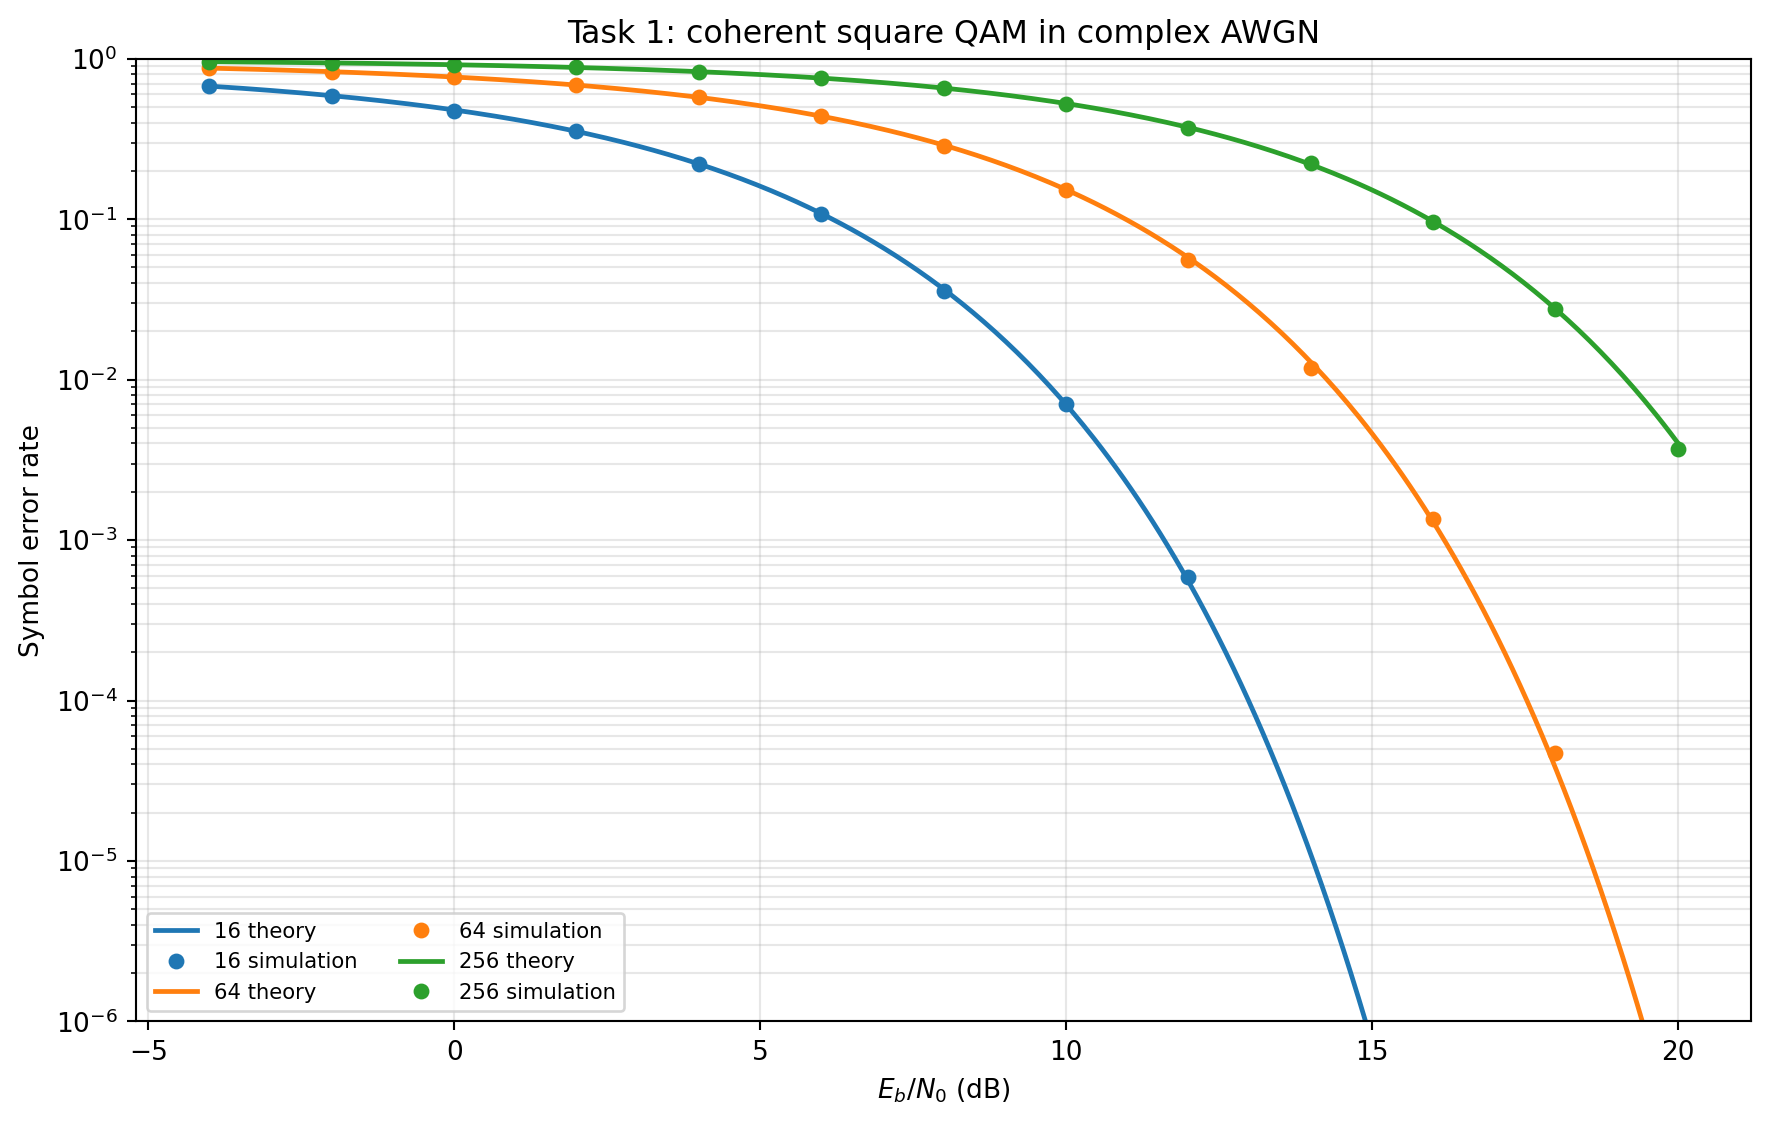

In [6]:
for order in (16, 64, 256):
    points = np.asarray(square_qam_constellation(order))
    assert points.size == order
    assert np.isclose(np.mean(np.abs(points)**2), 1.0)
    assert np.array_equal(minimum_distance_detector(points, points), np.arange(order))
print("QAM geometry and noiseless detection passed.")

rng = np.random.default_rng(7378)
qam_results = {}
for order in (16, 64, 256):
    constellation = square_qam_constellation(order)
    qam_results[order] = [
        simulate_awgn_point(constellation, ebn0, rng, minimum_distance_detector)
        for ebn0 in np.arange(-4.0, 20.1, 2.0)
    ]
qam_figure = plot_error_rate_results(
    qam_results, qam_theory_from_ebn0,
    "Task 1: coherent square QAM in complex AWGN",
    FIGURE_DIR, "task1_qam_error_rates"
)
display(Image(filename=str(qam_figure)))

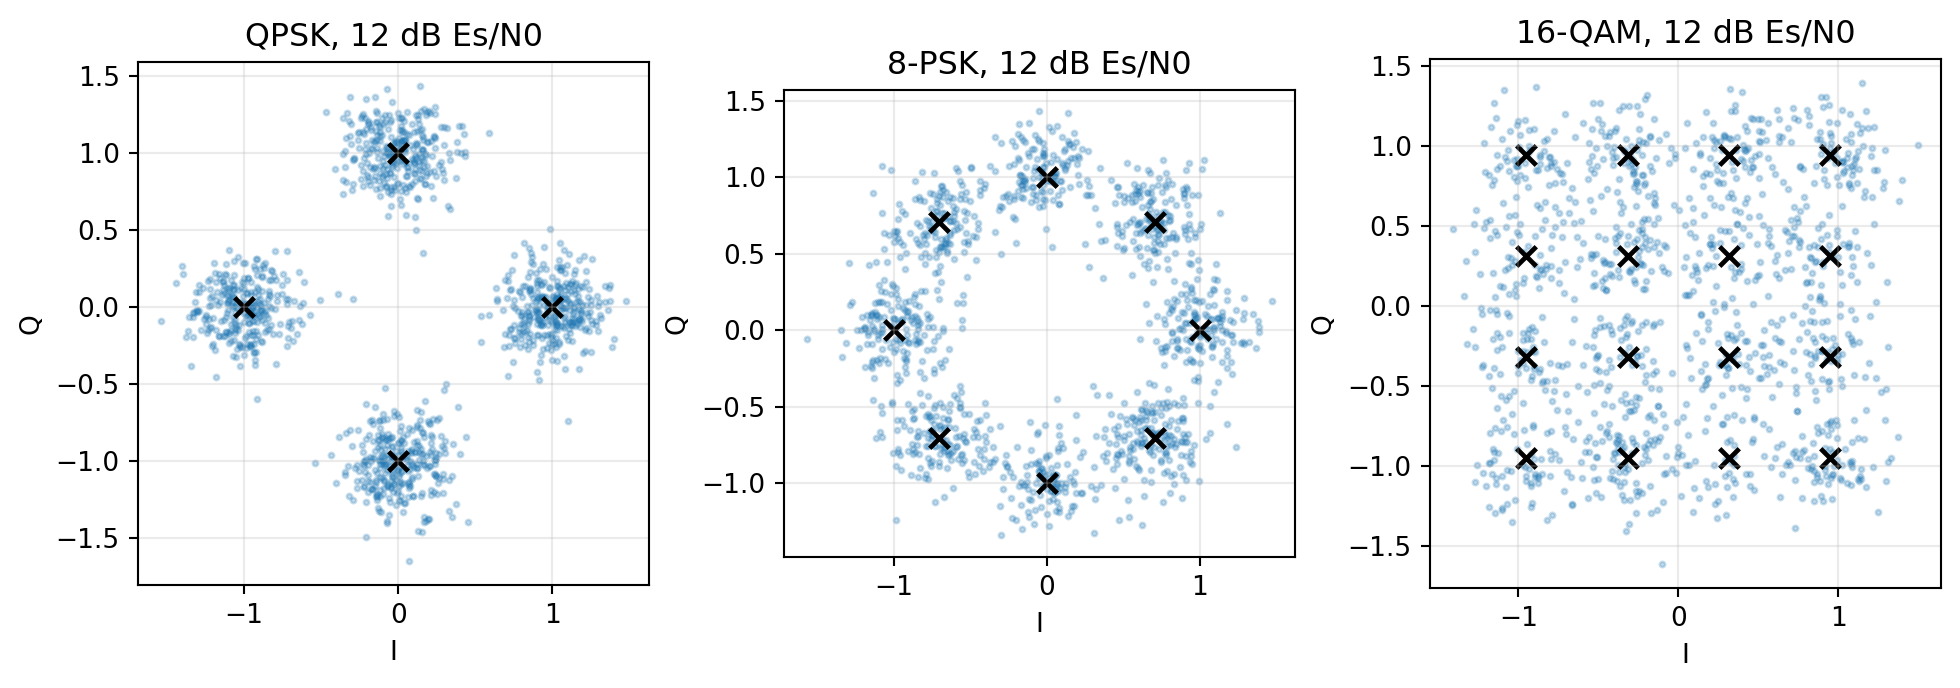

In [7]:
rng = np.random.default_rng(7379)
snapshots = []
for name, points in (
    ("QPSK, 12 dB Es/N0", psk_constellation(4)),
    ("8-PSK, 12 dB Es/N0", psk_constellation(8)),
    ("16-QAM, 12 dB Es/N0", square_qam_constellation(16)),
):
    labels = rng.integers(0, len(points), 1200)
    n0 = 10**(-12/10)
    noise = np.sqrt(n0/2)*(rng.standard_normal(labels.size) + 1j*rng.standard_normal(labels.size))
    snapshots.append((name, points[labels] + noise, points))
constellation_figure = plot_constellation_snapshots(snapshots, FIGURE_DIR)
display(Image(filename=str(constellation_figure)))

<span style="color:#165696"><b>Report.</b> State the input and output of the constellation, detector, AWGN, theory, simulation, and plotting stages. Verify average energy. Compare theory and simulation, compare modulation orders, and explain why SER and BER are different.</span>